In [154]:
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv('semiconductor_dataset/uci-secom.csv')
df.head()
df.columns

Index(['Time', '0', '1', '2', '3', '4', '5', '6', '7', '8',
       ...
       '581', '582', '583', '584', '585', '586', '587', '588', '589',
       'Pass/Fail'],
      dtype='str', length=592)

Preprocessing

In [155]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def preprocessing(df):
    df = df.copy()
    df = df.drop('Time', axis=1)

    #Drop columns with too many NA
    na_columns = df.columns[df.isna().mean() >= 0.25]
    df = df.drop(na_columns, axis=1)

    #Fill na
    for column in df.columns:
        df[column] = df[column].fillna(df[column].mean())

    df['Pass/Fail'] = df['Pass/Fail'].replace({-1:"PASS", 1:"FAIL"})

    y = df['Pass/Fail']
    X = df.drop('Pass/Fail', axis=1)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=1502)

    #Scaling
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = pd.DataFrame(scaler.transform(X_train), index=X_train.index, columns=X_train.columns)
    X_test = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

    #Delete unique value columns
    unique_value_columns = X_train.columns[(pd.Series({column:len(X_train[column].unique()) for column in X_train.columns}) == 1)]
    X_train = X_train.drop(unique_value_columns, axis=1)
    X_test = X_test.drop(unique_value_columns, axis=1)
    
    return X_train, X_test, y_train, y_test

In [156]:
X_train, X_test, y_train, y_test = preprocessing(df)

<Axes: xlabel='Pass/Fail'>

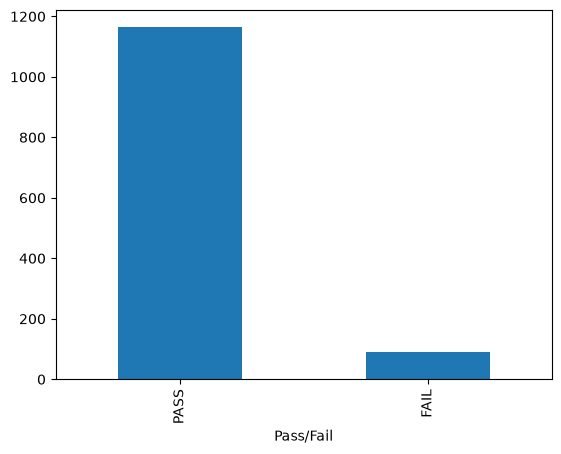

In [157]:
y_train.value_counts().plot.bar()

In [158]:
from imblearn.over_sampling import RandomOverSampler, SMOTE

sampler_ros = RandomOverSampler(random_state=15)
sampler_smote = SMOTE(random_state=15)
X_train_os, y_train_os = sampler_ros.fit_resample(X_train, y_train)
X_train_smote, y_train_smote = sampler_smote.fit_resample(X_train, y_train)

In [161]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [171]:
X_train_t, X_test_t = torch.from_numpy(X_train_os.values).float(), torch.from_numpy(X_test.values).float()
y_dict = {'PASS':1, 'FAIL':0}
y_train_n, y_test_n = pd.to_numeric(y_train_os.replace(y_dict)), pd.to_numeric(y_test.replace(y_dict))
y_train_t, y_test_t = torch.from_numpy(y_train_n.values), torch.from_numpy(y_test_n.values)